# Preprocessing #

Filtering, resampling, NaN handling (removal, imputation), epoching, and feature extraction/engineering.

In [1]:
from preprocessing.file_conversion import file_conversion
import numpy as np 

path = "/Users/reymendoza/Desktop/sleep_files"
X, X_scaled, y, groups = file_conversion(path)

Processing: sub-001_ses-001_task-sleep_acq-PSG_eeg.set
Reading /Users/reymendoza/Desktop/sleep_files/sub-001/ses-001/sub-001_ses-001_task-sleep_acq-PSG_eeg.fdt
Reading 0 ... 14255559  =      0.000 ... 28511.118 secs...
Creating RawArray with float64 data, n_channels=2, n_times=14255560
    Range : 0 ... 14255559 =      0.000 ... 28511.118 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 3301 samples (6.602 s)

  Feature matrix shape: (942, 50)
Processing: sub-001_ses-002_task-sleep_acq-PSG_ee

In [1]:
import numpy as np
#np.savez_compressed("sleep_dataset_20_6_2.npz", X=X, X_scaled=X_scaled, y=y, groups=groups)

data = np.load("/Users/reymendoza/Developer/Sleep-Stage-Classification/sleep_dataset_20_6_2.npz", allow_pickle=True)
X = data["X"]
X_scaled = data["X_scaled"]
y = data["y"]
groups = data["groups"]

# Random Forest


Class counts:
1     4601
2     5478
3    21138
Name: count, dtype: int64

Class proportions:
1    0.147
2    0.175
3    0.677
Name: proportion, dtype: float64

Fold 1/5
accuracy=0.7669, balanced_accuracy=0.7072, f1_macro=0.6781

Fold 2/5
accuracy=0.7167, balanced_accuracy=0.7160, f1_macro=0.6436

Fold 3/5
accuracy=0.8474, balanced_accuracy=0.8275, f1_macro=0.8081

Fold 4/5
accuracy=0.7849, balanced_accuracy=0.7274, f1_macro=0.7087

Fold 5/5
accuracy=0.8180, balanced_accuracy=0.7310, f1_macro=0.7498

Mean CV results:
accuracy: 0.7868
balanced_accuracy: 0.7418
precision_macro: 0.7232
recall_macro: 0.7418
f1_macro: 0.7177
precision_weighted: 0.8060
recall_weighted: 0.7868
f1_weighted: 0.7891
roc_auc_ovr_weighted: 0.8991

Classification report:
              precision    recall  f1-score   support

           1      0.589     0.844     0.694      4601
           2      0.660     0.540     0.594      5478
           3      0.876     0.835     0.855     21138

    accuracy                  

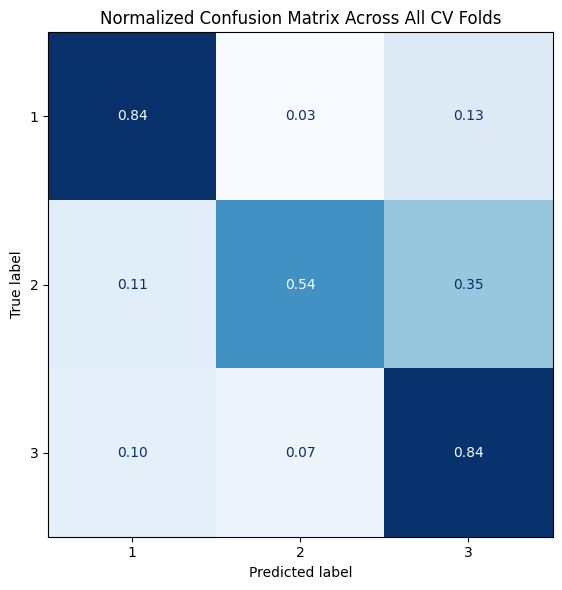

In [3]:
from metric_visualization import plot_normalized_confusion_matrix
from model import build_rf_model
from train import train, make_context_windows

def show_metrics(metrics):
    plot_normalized_confusion_matrix(
        cms=metrics["cms"],
        class_labels=metrics["class_labels"]
    )

model = build_rf_model()

metrics = train(X, y, groups, model, task='3-class')
show_metrics(metrics)

# Deep Learning Model Selection

Iterating through multiple different strategies for deep learning including LSTM & Attention frameworks and/or postprocessing alongisde Random Forest models.

In [2]:
from sklearn.metrics import classification_report
from train import train_hybrid_flexible
import pandas as pd
import numpy as np
import tensorflow as tf

experiment_configs = [
    {"name": "CNN", "feature": False, "lstm": False, "rf": False},
    {"name": "CNN+LSTM", "feature": False, "lstm": True, "rf": False},
    {"name": "CNN+FEAT", "feature": True, "lstm": False, "rf": False},
    {"name": "CNN+FEAT+LSTM", "feature": True, "lstm": True, "rf": False},
    {"name": "CNN+RF", "feature": False, "lstm": False, "rf": True},
    {"name": "CNN+FEAT+RF", "feature": True, "lstm": False, "rf": True},
    {"name": "CNN+LSTM+RF", "feature": False, "lstm": True, "rf": True},
    {"name": "FULL_MODEL", "feature": True, "lstm": True, "rf": True},
]
results_table = []

np.random.seed(42)
tf.random.set_seed(42)

for config in experiment_configs:

    print("\n" + "="*60)
    print(f"Running: {config['name']}")
    print("="*60)

    metrics = train_hybrid_flexible(
        X_scaled,
        X,
        y,
        groups,

        use_feature_branch=config["feature"],
        use_lstm_attention=config["lstm"],
        use_rf_ensemble=config["rf"]
    )

    summary = metrics["summary"]
    y_true = metrics["all_y_true"]
    y_pred = metrics["all_y_pred"]

    report = classification_report(y_true, y_pred, output_dict=True)

    results_table.append({
        "model": config["name"],
        "features": config["feature"],
        "lstm": config["lstm"],
        "rf": config["rf"],

        "accuracy": summary["accuracy"],
        "balanced_accuracy": summary["balanced_accuracy"],
        "f1_macro": summary["f1_macro"],

        "class1_recall": report["1"]["recall"],
        "class2_recall": report["2"]["recall"],
        "class3_recall": report["3"]["recall"],

        "std_bal_acc": np.std(
            [f["balanced_accuracy"] for f in metrics["fold_results"]]
        )
    })

df = pd.DataFrame(results_table)

df["score"] = 0.5 * df["balanced_accuracy"] + 0.5 * df["f1_macro"]

df = df.sort_values(by="score", ascending=False)

print("\nFINAL RESULTS:\n")
print(df)


Running: CNN

Model config → feature=False, lstm=False, rf=False

Class counts:
1     4601
2     5478
3    21138
Name: count, dtype: int64

Class proportions:
1    0.147
2    0.175
3    0.677
Name: proportion, dtype: float64

================ Fold 1/5 ================
Epoch 1/40
3068/3068 - 163s - 53ms/step - accuracy: 0.5565 - loss: 0.9278 - val_accuracy: 0.6290 - val_loss: 0.8274 - learning_rate: 1.0000e-04
Epoch 2/40
3068/3068 - 148s - 48ms/step - accuracy: 0.6571 - loss: 0.7486 - val_accuracy: 0.6724 - val_loss: 0.7556 - learning_rate: 1.0000e-04
Epoch 3/40
3068/3068 - 152s - 50ms/step - accuracy: 0.6950 - loss: 0.6682 - val_accuracy: 0.6830 - val_loss: 0.7405 - learning_rate: 1.0000e-04
Epoch 4/40
3068/3068 - 156s - 51ms/step - accuracy: 0.7233 - loss: 0.6122 - val_accuracy: 0.7015 - val_loss: 0.7453 - learning_rate: 1.0000e-04
Epoch 5/40
3068/3068 - 158s - 52ms/step - accuracy: 0.7394 - loss: 0.5760 - val_accuracy: 0.6848 - val_loss: 0.7413 - learning_rate: 1.0000e-04
Epoch 6/40

Python(35131) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


accuracy=0.8418, balanced_accuracy=0.7959, f1_macro=0.7835

================ Fold 2/5 ================
Epoch 1/40
3083/3083 - 153s - 50ms/step - accuracy: 0.6094 - loss: 0.9242 - val_accuracy: 0.6681 - val_loss: 0.7622 - learning_rate: 1.0000e-04
Epoch 2/40
3083/3083 - 144s - 47ms/step - accuracy: 0.6488 - loss: 0.7665 - val_accuracy: 0.6755 - val_loss: 0.7160 - learning_rate: 1.0000e-04
Epoch 3/40
3083/3083 - 137s - 44ms/step - accuracy: 0.6939 - loss: 0.6728 - val_accuracy: 0.6870 - val_loss: 0.7122 - learning_rate: 1.0000e-04
Epoch 4/40
3083/3083 - 138s - 45ms/step - accuracy: 0.7232 - loss: 0.6107 - val_accuracy: 0.7025 - val_loss: 0.6927 - learning_rate: 1.0000e-04
Epoch 5/40
3083/3083 - 147s - 48ms/step - accuracy: 0.7477 - loss: 0.5671 - val_accuracy: 0.6918 - val_loss: 0.7225 - learning_rate: 1.0000e-04
Epoch 6/40
3083/3083 - 137s - 44ms/step - accuracy: 0.7632 - loss: 0.5388 - val_accuracy: 0.7346 - val_loss: 0.6735 - learning_rate: 1.0000e-04
Epoch 7/40
3083/3083 - 139s - 45m

The best performing classification strategy was a CNN model with a raw signal head and a feature head running adjacent to a random forest model on the features, and both models' outputs are averaged. Notably, only strategies with an adjacent Random Forest performed better. More importantly, it appears that approaches that utilized LSTM and attention were the weakest performers, which might suggest that giving more context to the model actually results in weaker classification metrics.

In [3]:
df

,model,features,lstm,rf,accuracy,balanced_accuracy,f1_macro,class1_recall,class2_recall,class3_recall,std_bal_acc,score
5,CNN+FEAT+RF,True,False,True,0.810276,0.795106,0.759869,0.848071,0.709171,0.825161,0.031127,0.777488
4,CNN+RF,False,False,True,0.804407,0.787663,0.753160,0.850717,0.683778,0.822274,0.045256,0.770411
6,CNN+LSTM+RF,False,True,True,0.795252,0.790198,0.746084,0.847850,0.714651,0.800786,0.047291,0.768141
2,CNN+FEAT,True,False,False,0.792988,0.787904,0.744600,0.820948,0.735477,0.798656,0.039584,0.766252
7,FULL_MODEL,True,True,True,0.788057,0.776573,0.736217,0.858655,0.662952,0.800549,0.047060,0.756395
1,CNN+LSTM,False,True,False,0.764416,0.781723,0.721226,0.821830,0.759043,0.748769,0.072792,0.751474
0,CNN,False,False,False,0.773309,0.772232,0.724728,0.812128,0.714103,0.778067,0.060422,0.748480
3,CNN+FEAT+LSTM,True,True,False,0.763022,0.770148,0.714272,0.827122,0.709901,0.758425,0.054459,0.742210


# Best Post-Processing Strategy

In [3]:
from metric_visualization import plot_normalized_confusion_matrix
from train import sleep_model_train_weight_smoothing_sweep

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

# weights
weights = np.round(np.arange(0.3, 0.85, 0.05), 2)

# smoothing
smoothing_windows = [1, 3, 5, 7]

# 🔥 contexts to test
contexts = [1, 3, 5]

all_results = []

print("\n" + "="*60)
print("Running CONTEXT + WEIGHT + SMOOTHING SWEEP")
print("="*60)

for ctx in contexts:

    print("\n" + "-"*60)
    print(f"Running context: {ctx}")
    print("-"*60)

    df = sleep_model_train_weight_smoothing_sweep(
        X_scaled, 
        X, 
        y,
        groups,
        rf_weights=weights,
        smoothing_windows=smoothing_windows,
        n_splits=5,
        context=ctx
    )

    # 🔥 tag context
    df["context"] = ctx

    all_results.append(df)

# combine all
last_df = pd.concat(all_results, ignore_index=True)

# scoring
last_df = last_df.sort_values(by="score", ascending=False)

print("\nFINAL RESULTS:\n")
print(last_df)


Running CONTEXT + WEIGHT + SMOOTHING SWEEP

------------------------------------------------------------
Running context: 1
------------------------------------------------------------

Running WEIGHT + SMOOTHING SWEEP

Class counts:
1     4601
2     5478
3    21138
Name: count, dtype: int64

Class proportions:
1    0.147
2    0.175
3    0.677
Name: proportion, dtype: float64

================ Fold 1/5 ================
Epoch 1/40
3091/3091 - 41s - 13ms/step - accuracy: 0.5687 - loss: 0.8763 - val_accuracy: 0.7511 - val_loss: 0.6787 - learning_rate: 1.0000e-04
Epoch 2/40
3091/3091 - 36s - 12ms/step - accuracy: 0.6553 - loss: 0.7275 - val_accuracy: 0.7652 - val_loss: 0.7163 - learning_rate: 1.0000e-04
Epoch 3/40
3091/3091 - 36s - 12ms/step - accuracy: 0.6771 - loss: 0.6759 - val_accuracy: 0.7635 - val_loss: 0.8214 - learning_rate: 1.0000e-04
Epoch 4/40

Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
3091/3091 - 35s - 11ms/step - accuracy: 0.6859 - loss: 0.64

The best performing post-processing strategies gave a stronger weight towards CNN's predictions and less on Random Forest predictions. Also a higher smoothing window provided better overall classification. Additionally to post-processing, a higher context window proved better classification.

In [13]:
last_df

,rf_weight,cnn_weight,smoothing,accuracy,balanced_accuracy,f1_macro,score,context
88,0.35,0.65,7,0.815723,0.794134,0.762276,0.778205,5
89,0.30,0.70,7,0.815293,0.794317,0.761850,0.778084,5
90,0.40,0.60,7,0.815340,0.792830,0.761830,0.777330,5
91,0.35,0.65,5,0.812471,0.793658,0.759201,0.776430,5
92,0.45,0.55,7,0.815061,0.791035,0.761076,0.776055,5
...,...,...,...,...,...,...,...,...
86,0.75,0.25,1,0.768372,0.744821,0.705095,0.724958,3
41,0.70,0.30,1,0.764293,0.744927,0.704711,0.724819,1
87,0.80,0.20,1,0.766952,0.740962,0.702523,0.721743,3
42,0.75,0.25,1,0.763912,0.740997,0.702308,0.721652,1



 RUNNING FINAL BEST MODEL

Class counts:
1     4601
2     5478
3    21138
Name: count, dtype: int64

Class proportions:
1    0.147
2    0.175
3    0.677
Name: proportion, dtype: float64

================ Fold 1/5 ================
Epoch 1/40
3068/3068 - 162s - 53ms/step - accuracy: 0.6124 - loss: 0.8336 - val_accuracy: 0.6327 - val_loss: 0.7905 - learning_rate: 1.0000e-04
Epoch 2/40
3068/3068 - 153s - 50ms/step - accuracy: 0.6728 - loss: 0.6712 - val_accuracy: 0.6542 - val_loss: 0.7220 - learning_rate: 1.0000e-04
Epoch 3/40
3068/3068 - 157s - 51ms/step - accuracy: 0.6973 - loss: 0.6077 - val_accuracy: 0.6469 - val_loss: 0.7551 - learning_rate: 1.0000e-04
Epoch 4/40
3068/3068 - 160s - 52ms/step - accuracy: 0.7130 - loss: 0.5712 - val_accuracy: 0.6590 - val_loss: 0.7508 - learning_rate: 1.0000e-04
Epoch 5/40
3068/3068 - 156s - 51ms/step - accuracy: 0.7253 - loss: 0.5515 - val_accuracy: 0.6643 - val_loss: 0.6928 - learning_rate: 1.0000e-04
Epoch 6/40
3068/3068 - 153s - 50ms/step - accurac

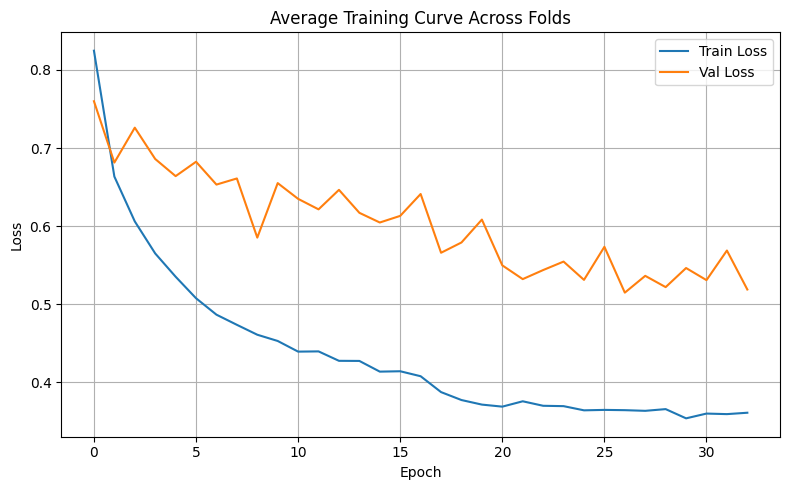


Row-normalized confusion matrix:
[[0.81345094 0.0862183  0.10033076]
 [0.0971867  0.78498356 0.11782974]
 [0.09982014 0.11941499 0.78076486]]


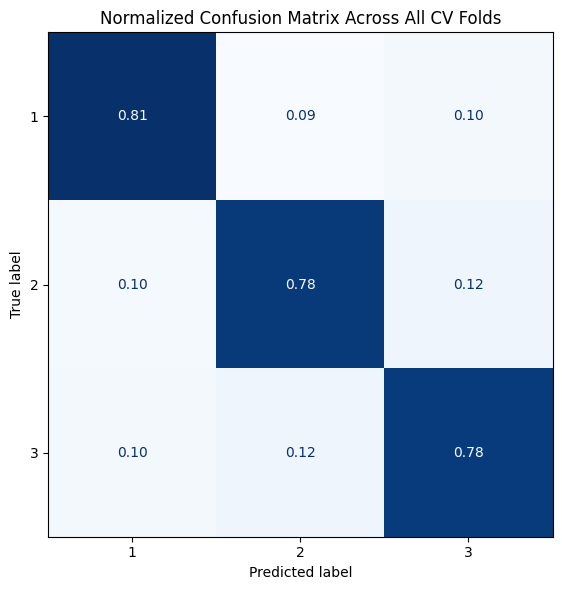

In [3]:
from metric_visualization import plot_normalized_confusion_matrix
from train import sleep_model_train

metrics = sleep_model_train(
    X_signal=X_scaled,
    X_features=X,
    y=y,
    groups=groups
)

plot_normalized_confusion_matrix(
    cms=metrics["cms"],
    class_labels=metrics["class_labels"]
)